In [ ]:
import openai

openai.__version__

'1.66.3'

In [1]:
import time
import base64
from openai import OpenAI

client = OpenAI()

def encode_image(image_path):
    with open(image_path, "rb") as image_file:
        return base64.b64encode(image_file.read()).decode("utf-8")
    
def get_token_stats(response):
    token_stats = {
        "prompt_tokens": response.usage.prompt_tokens,
        "completion_tokens": response.usage.completion_tokens,
        "total_tokens": response.usage.total_tokens,
    }
    return token_stats

def ask_gpt(user_query, base64_image, model="gpt-4.5-preview"):
    start_time = time.time()
    response = client.chat.completions.create(
        model=model,
        messages=[
            {
                "role": "user",
                "content": [
                    { "type": "text", "text": user_query },
                    {
                        "type": "image_url",
                        "image_url": {
                            "url": f"data:image/jpeg;base64,{base64_image}",
                        },
                    },
                ],
            }
        ],
    )
    latency = time.time() - start_time
    answer = response.choices[0].message.content
    token_stats = get_token_stats(response)
    return answer, token_stats, latency

def ask_gpt_with_structured_output(user_query, base64_image, response_format, model="gpt-4.5-preview"):
    start_time = time.time()
    response = client.beta.chat.completions.parse(
        model=model,
        messages=[
            {
                "role": "user",
                "content": [
                    { "type": "text", "text": user_query },
                    {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{base64_image}",},},
                ],
            }
        ],
        response_format=response_format
    )
    latency = time.time() - start_time
    answer = response.choices[0].message.parsed
    token_stats = get_token_stats(response)
    return answer, token_stats, latency

# Object Detection

In [2]:
from pydantic import BaseModel
from typing import List

class Detections(BaseModel):
    detected_class: str
    x_min: float
    x_max: float
    y_min: float
    y_max: float

class Detections(BaseModel):
    detections: List[Detections]

user_query = "Detect the food and its location in the image. " \
"Normalize the coordinates between 0 and 1 based on image width and height."

In [3]:
image_path = "images/brunch.jpeg"
base64_image = encode_image(image_path)
answer, token_stats, latency = ask_gpt_with_structured_output(user_query, 
                                                              base64_image, 
                                                              response_format=Detections)

In [4]:
answer.detections

[Detections(detected_class='food', x_min=0.03196803196803197, x_max=0.9315329315329315, y_min=0.45708154506437765, y_max=0.8802547770700637),
 Detections(detected_class='food', x_min=0.7604257604257604, x_max=0.948339483394834, y_min=0.4820325305749849, y_max=0.6613508427437709)]

In [5]:
token_stats

{'prompt_tokens': 1273, 'completion_tokens': 114, 'total_tokens': 1387}

In [6]:
latency

16.022588968276978

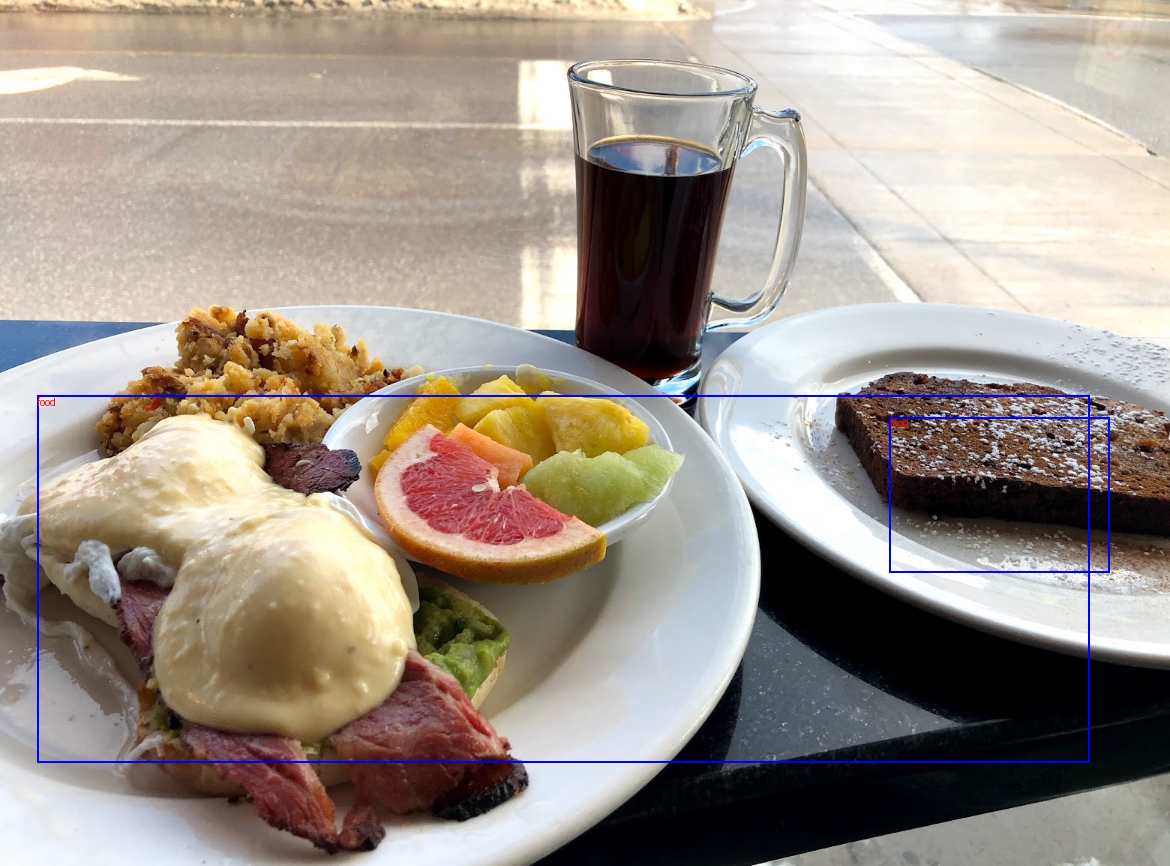

In [7]:
from PIL import Image
from PIL import ImageDraw


image = Image.open(image_path).convert("RGB")
draw = ImageDraw.Draw(image)

width, height = image.size

for i, detection in enumerate(answer.detections):
    x1, x2 = detection.x_min * width, detection.x_max * width
    y1, y2 = detection.y_min * height, detection.y_max * height
    draw.rectangle(((x1, y1), (x2, y2)), outline="blue", width=2)
    draw.text((x1, y1), detection.detected_class, fill="red")

image

In [8]:
image_path = "images/nutrition5k-1.png"
base64_image = encode_image(image_path)
answer, token_stats, latency = ask_gpt_with_structured_output(user_query, 
                                                              base64_image, 
                                                              response_format=Detections)

In [9]:
answer.detections

[Detections(detected_class='potato', x_min=0.40625, x_max=0.703125, y_min=0.2765625, y_max=0.4765625),
 Detections(detected_class='bacon', x_min=0.5734375, x_max=0.8453125, y_min=0.503125, y_max=0.703125),
 Detections(detected_class='melon', x_min=0.28125, x_max=0.5546875, y_min=0.56875, y_max=0.790625)]

In [10]:
token_stats

{'prompt_tokens': 593, 'completion_tokens': 128, 'total_tokens': 721}

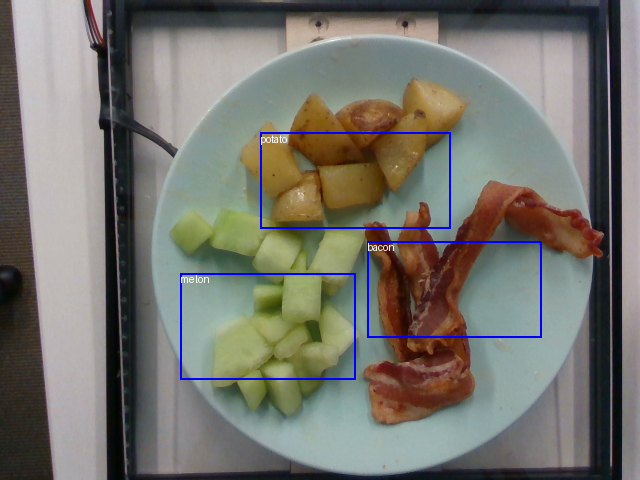

In [11]:
from PIL import Image
from PIL import ImageDraw


image = Image.open(image_path).convert("RGB")
draw = ImageDraw.Draw(image)
width, height = image.size

for i, detection in enumerate(answer.detections):
    x1, x2 = detection.x_min * width, detection.x_max * width
    y1, y2 = detection.y_min * height, detection.y_max * height
    draw.rectangle(((x1, y1), (x2, y2)), outline="blue", width=2)
    draw.text((x1, y1), detection.detected_class)

image

# Visual Question Answering

In [12]:
user_query = """
Detect the foods in the image.
What are macro nutrients of each food?
What are micro nutrients of each food?
What is the calorie count of each food?
What is the serving size of each food?
"""

In [13]:
image_path = "images/nutrition5k-1.png"
base64_image = encode_image(image_path)
answer, token_stats, latency = ask_gpt(user_query, 
                                       base64_image)

In [14]:
print(answer)

The foods detected in the image appear to be potato wedges, bacon strips, and honeydew melon cubes. Below is the nutritional information for each item, based on average standard serving sizes:

1. Potato Wedges (Roasted):
- Macronutrients (per 100g serving size):
  - Carbohydrates: 17g
  - Protein: 2g
  - Fat: 4.5g
- Micronutrients:
  - Potassium
  - Vitamin C
  - Vitamin B6
- Calorie Count: Approximately 120 kcal per 100g serving.
- Serving Size: Approximately 100g per standard serving.

2. Bacon Strips:
- Macronutrients (per 2 cooked slices, about 16g):
  - Carbohydrates: 0.1g
  - Protein: 5g
  - Fat: 7g
- Micronutrients:
  - Sodium
  - Potassium
  - Phosphorus
- Calorie Count: Approximately 80 kcal per 2 slices serving.
- Serving Size: 2 strips (approximately 16g).

3. Honeydew Melon Cubes:
- Macronutrients (per 1 cup diced, about 177g):
  - Carbohydrates: 16g
  - Protein: 1g
  - Fat: 0.3g
- Micronutrients:
  - Vitamin C
  - Vitamin B6
  - Folate
  - Potassium
- Calorie Count: Appro

In [15]:
token_stats

{'prompt_tokens': 474, 'completion_tokens': 361, 'total_tokens': 835}

In [17]:
image_path = "images/brunch.jpeg"
base64_image = encode_image(image_path)
answer, token_stats, latency = ask_gpt(user_query, 
                                       base64_image)

In [18]:
print(answer)

The foods detected in the image include:

1. Eggs Benedict:
Serving Size: Typically 1 serving (2 eggs with hollandaise and Canadian bacon on an English muffin)
Calorie count: Approximately 550 calories per serving
Macronutrients:
- Protein: 21g
- Carbohydrates: 28g
- Fats: 40g
Micronutrients: Rich in Vitamin A, Vitamin D, Calcium, Iron, Vitamin B12

2. Hash Browns or Breakfast Potatoes:
Serving Size: Approximately 1 cup (150 g)
Calorie count: Approximately 300 calories per serving 
Macronutrients:
- Protein: 4g
- Carbohydrates: 35g
- Fats: 15g
Micronutrients: Potassium, Vitamin C, Iron, Vitamin B6, Fiber

3. Fresh Fruit Mix (grapefruit, pineapple, melon, oranges):
Serving Size: Approximately 1 cup (150 g)
Calorie count: Approximately 70 calories per serving
Macronutrients:
- Protein: 1g
- Carbohydrates: 18g
- Fats: 0g
Micronutrients: Vitamin C, Vitamin A, Potassium, Folate, Dietary Fiber, Antioxidants

4. Dark Rye or Whole Wheat Toast:
Serving Size: Approximately 1 slice, 32 g
Calorie 

In [19]:
user_query = """
I have some photos for which I want you to provide me with an estimate of 
the nutritional content. Specifically, I want you to give me an estimate of energy, protein,
total carbohydrate, total fat, dietary fibre, total sugar, saturated fat, polyunsaturated fat,
monounsaturated fat, calcium, iron, vitamin D, sodium, potassium, folate, folic acid, and
vitamin C in the total meal. Please also provide a list of the foods in the photo with an
estimate of the physical weight of each food in grams. Please provide your best point
estimate and do not provide a range. When estimating the weight, please provide a weight
estimate for each individual ingredient you identify in the meal rather than the combined
weights of multiple ingredients." \
"""

In [20]:
image_path = "images/nutrition5k-1.png"
base64_image = encode_image(image_path)
answer, token_stats, latency = ask_gpt(user_query, 
                                       base64_image)

In [21]:
print(answer)

Food items identified with estimated weights:

1. Roasted Potatoes (plain, skin-on): 80 grams
2. Bacon (crispy, pan-fried): 30 grams
3. Honeydew Melon Pieces: 70 grams

Estimated Nutritional Content (Total Meal):

- Energy: 250 kcal
- Protein: 9 g
- Total Carbohydrate: 27 g
- Total Fat: 12 g
- Dietary Fiber: 2 g
- Total Sugars: 10 g
- Saturated Fat: 4 g
- Polyunsaturated Fat: 2 g
- Monounsaturated Fat: 5 g
- Calcium: 15 mg
- Iron: 1 mg
- Vitamin D: 0.3 µg
- Sodium: 400 mg
- Potassium: 600 mg
- Folate: 25 µg
- Folic Acid: 0 µg
- Vitamin C: 20 mg

These are approximate estimates and actual nutrient values may differ.


# Document Understanding

In [22]:
user_query = "How much did I pay for the meal? How much tax did I pay? " \
"Which date is that and what is the name of the restaurant?"

image_path = "images/restaurant-bill.jpg"
base64_image = encode_image(image_path)
answer, token_stats, latency = ask_gpt(user_query, 
                                       base64_image)

In [23]:
print(answer)

You paid a total of $85.88 for the meal. The tax amount paid was $5.88. The date of this visit was December 27, 2022. The name of the restaurant is Nomade Westport Restaurant.


In [24]:
user_query = "What is the price of Ravioli di Carne? What are its ingredients?"

image_path = "images/menu-pasta-1.jpeg"
base64_image = encode_image(image_path)
answer, token_stats, latency = ask_gpt(user_query, 
                                       base64_image)

In [25]:
print(answer)

The price of Ravioli di Carne is $23.00. Its ingredients are beef stuffed pasta in a light bolognese sauce.


In [26]:
user_query = "What is the price of spaghetti allo scoglio? What are its ingredients?"

image_path = "images/menu-pasta-2.jpeg"
base64_image = encode_image(image_path)
answer, token_stats, latency = ask_gpt(user_query, 
                                       base64_image)

In [27]:
print(answer)

The price of Spaghetti allo scoglio is $28.00. Its ingredients are chopped garlic, mussels, shrimps, scallops, clams, and cherry tomatoes.
